In [ ]:
# data/WayMo/Processed/00000_8_cb3413b9e69ae5ab

In [2]:
import yaml
import pandas as pd
from tqdm import tqdm
from itertools import islice
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

def get_df_data(scenario, use_tqdm=False):
    df_list = []
    for track in tqdm(scenario.tracks, disable=not use_tqdm):
        for frame, state in enumerate(track.states):
            if state.valid:
                row = dict(
                    center_x=state.center_x,
                    center_y=state.center_y,
                    center_z=state.center_z,
                    length=state.length,
                    width=state.width,
                    height=state.height,
                    heading=state.heading,
                    velocity_x=state.velocity_x,
                    velocity_y=state.velocity_y,
                    f=frame,
                    id=track.id,
                    type=track.object_type,
                )
                df_list.append(row)
    df = pd.DataFrame(df_list)
    df['type'] = df['type'].map({0: 'UNSET', 1: 'VEHICLE', 2: 'PEDESTRIAN', 3: 'CYCLIST', 4: 'OTHER'})
    return df

filename = "./data/WayMo/Motion/training_20s.tfrecord-00000-of-01000"
scenario_idx = 8  # 选择这个数据集文件中的第 2 个场景

dataset = tf.data.TFRecordDataset(filename, compression_type='')
data = next(islice(dataset, scenario_idx, None), None)
scenario = scenario_pb2.Scenario()
scenario.ParseFromString(data.numpy())
print("Scenario ID:", scenario.scenario_id)
print("Number of tracks:", len(scenario.tracks))
print("Map features:", len(scenario.map_features))
df = get_df_data(scenario, use_tqdm=True)
df

Scenario ID: cb3413b9e69ae5ab
Number of tracks: 74
Map features: 548


100%|██████████| 74/74 [00:00<00:00, 2663.30it/s]


,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y,f,id,type
0,1618.980591,-5739.129883,-17.432516,4.229386,1.935130,1.688108,2.404286,-0.366211,0.424805,0,575,VEHICLE
1,1618.943970,-5739.087402,-17.434837,4.231256,1.925984,1.690058,2.402258,-0.366211,0.424805,1,575,VEHICLE
2,1618.955811,-5739.089355,-17.431426,4.215407,1.925317,1.694431,2.398935,0.118408,-0.019531,2,575,VEHICLE
3,1618.944580,-5739.079102,-17.433841,4.220625,1.929169,1.703189,2.396437,-0.112305,0.102539,3,575,VEHICLE
4,1618.950073,-5739.081543,-17.435898,4.211189,1.925509,1.700127,2.397909,0.054932,-0.024414,4,575,VEHICLE
...,...,...,...,...,...,...,...,...,...,...,...,...
8136,1648.829132,-5710.903758,-16.928576,5.286000,2.332000,2.330000,1.731259,-0.946551,4.334041,194,780,VEHICLE
8137,1648.729344,-5710.467648,-16.930800,5.286000,2.332000,2.330000,1.749263,-1.047621,4.407350,195,780,VEHICLE
8138,1648.620197,-5710.024768,-16.933808,5.286000,2.332000,2.330000,1.767574,-1.138800,4.470177,196,780,VEHICLE
8139,1648.502253,-5709.576234,-16.936134,5.286000,2.332000,2.330000,1.785383,-1.231960,4.525229,197,780,VEHICLE


1572.2991638183594 1730.4935134887696 -5801.973364257812 -5632.039246826172


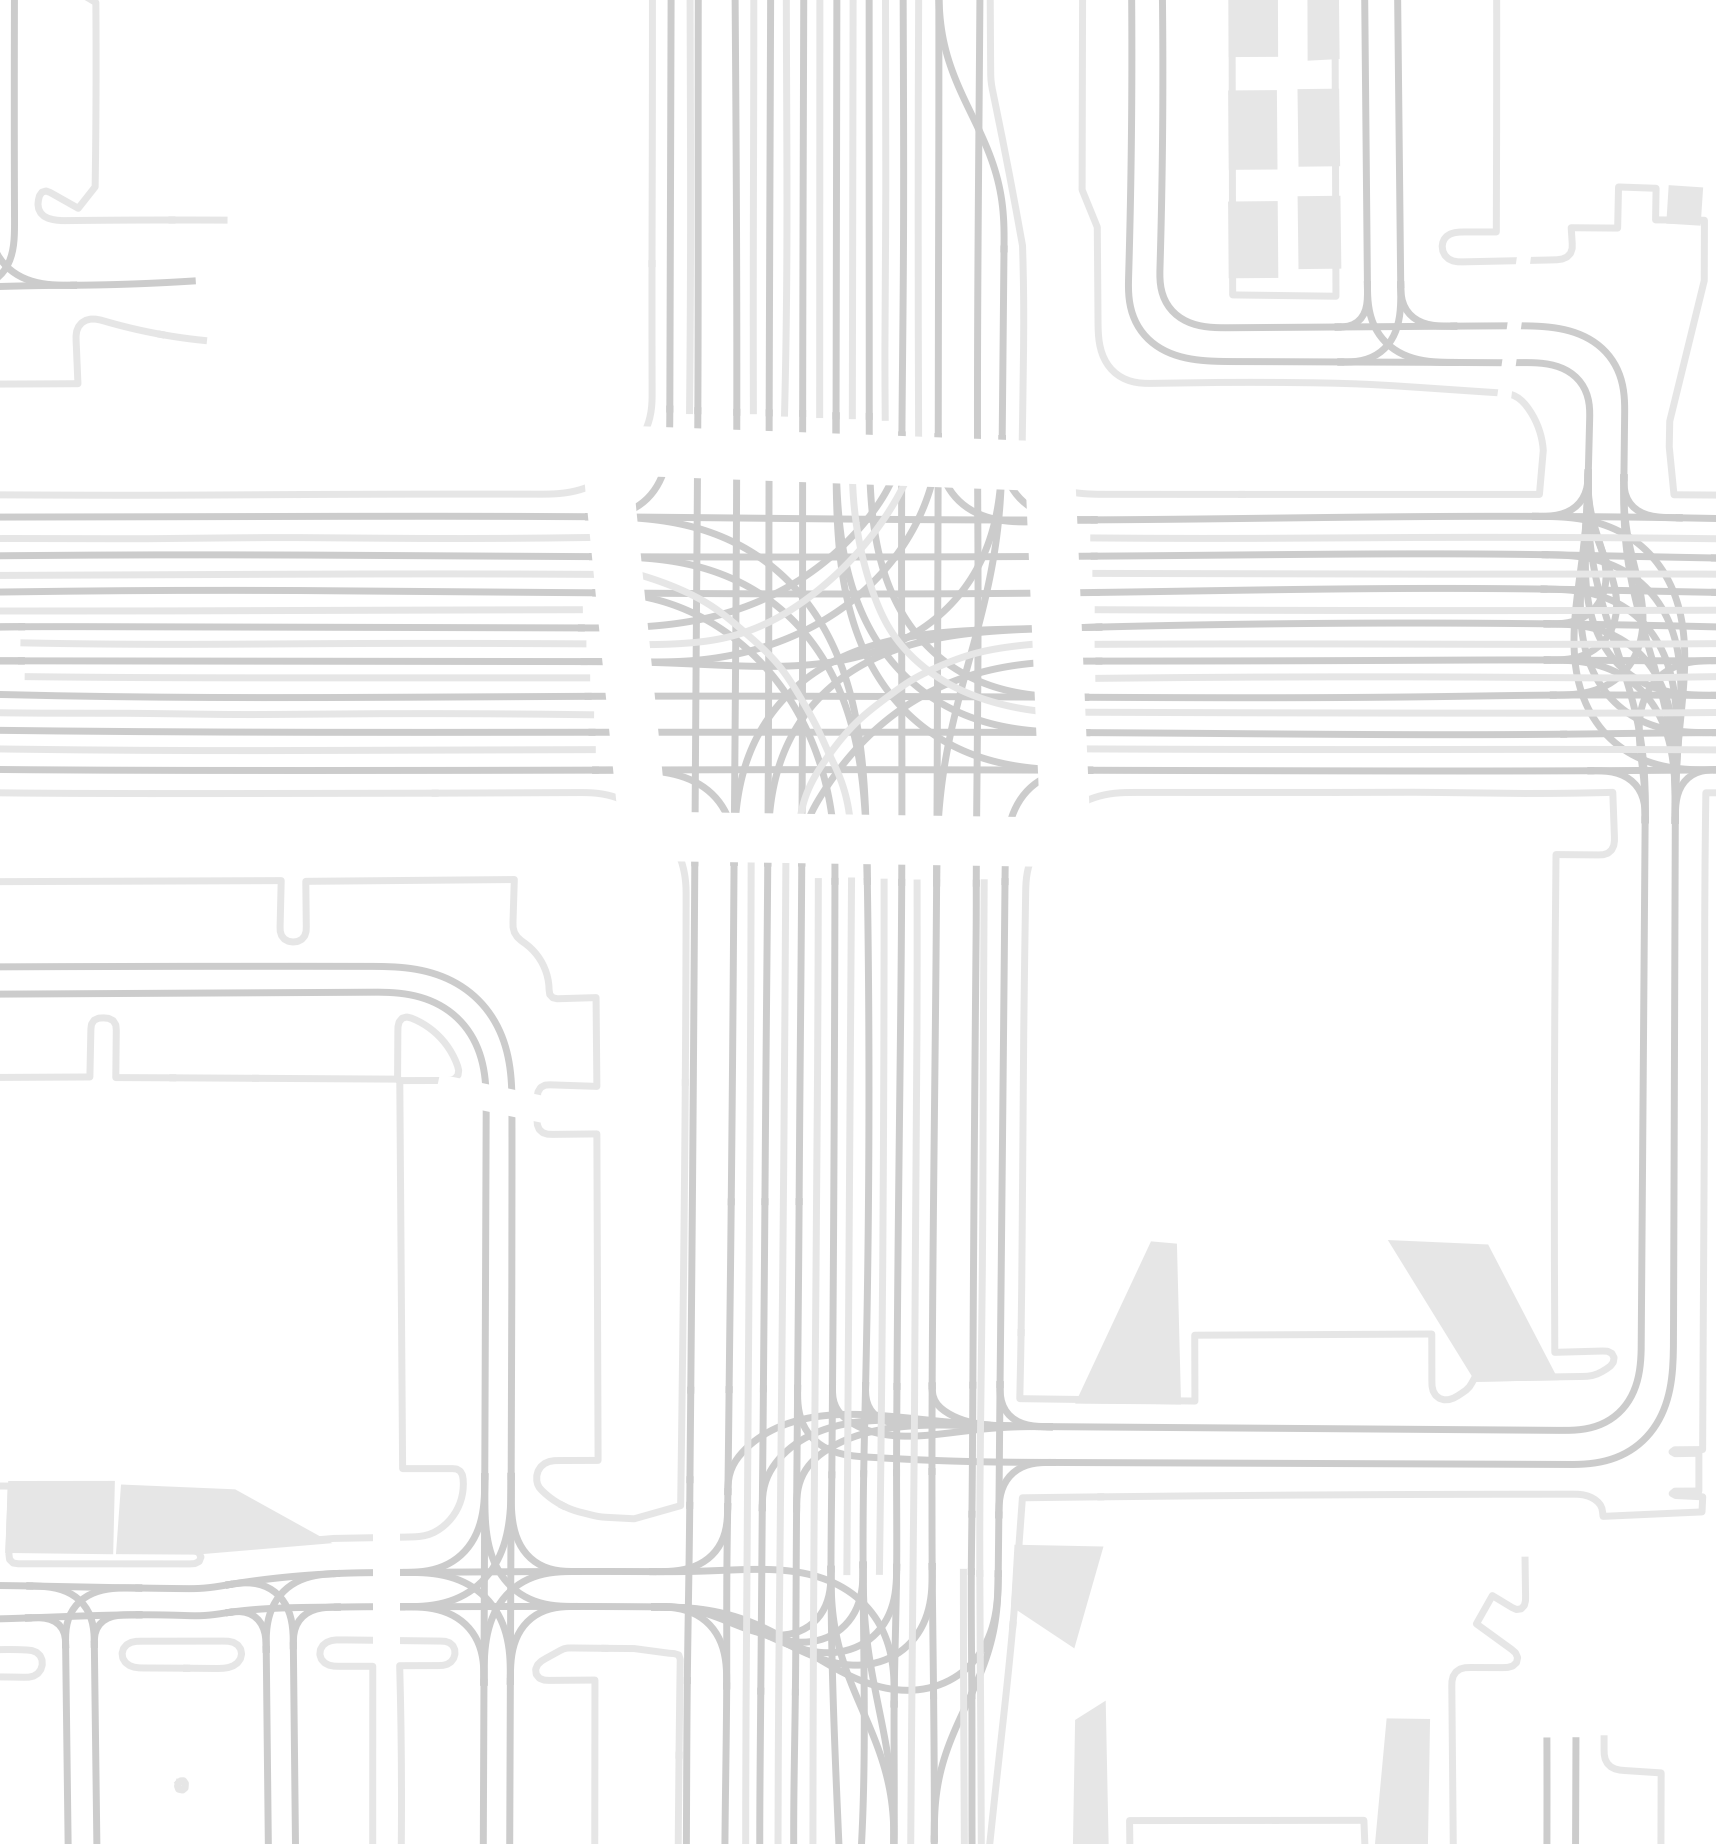

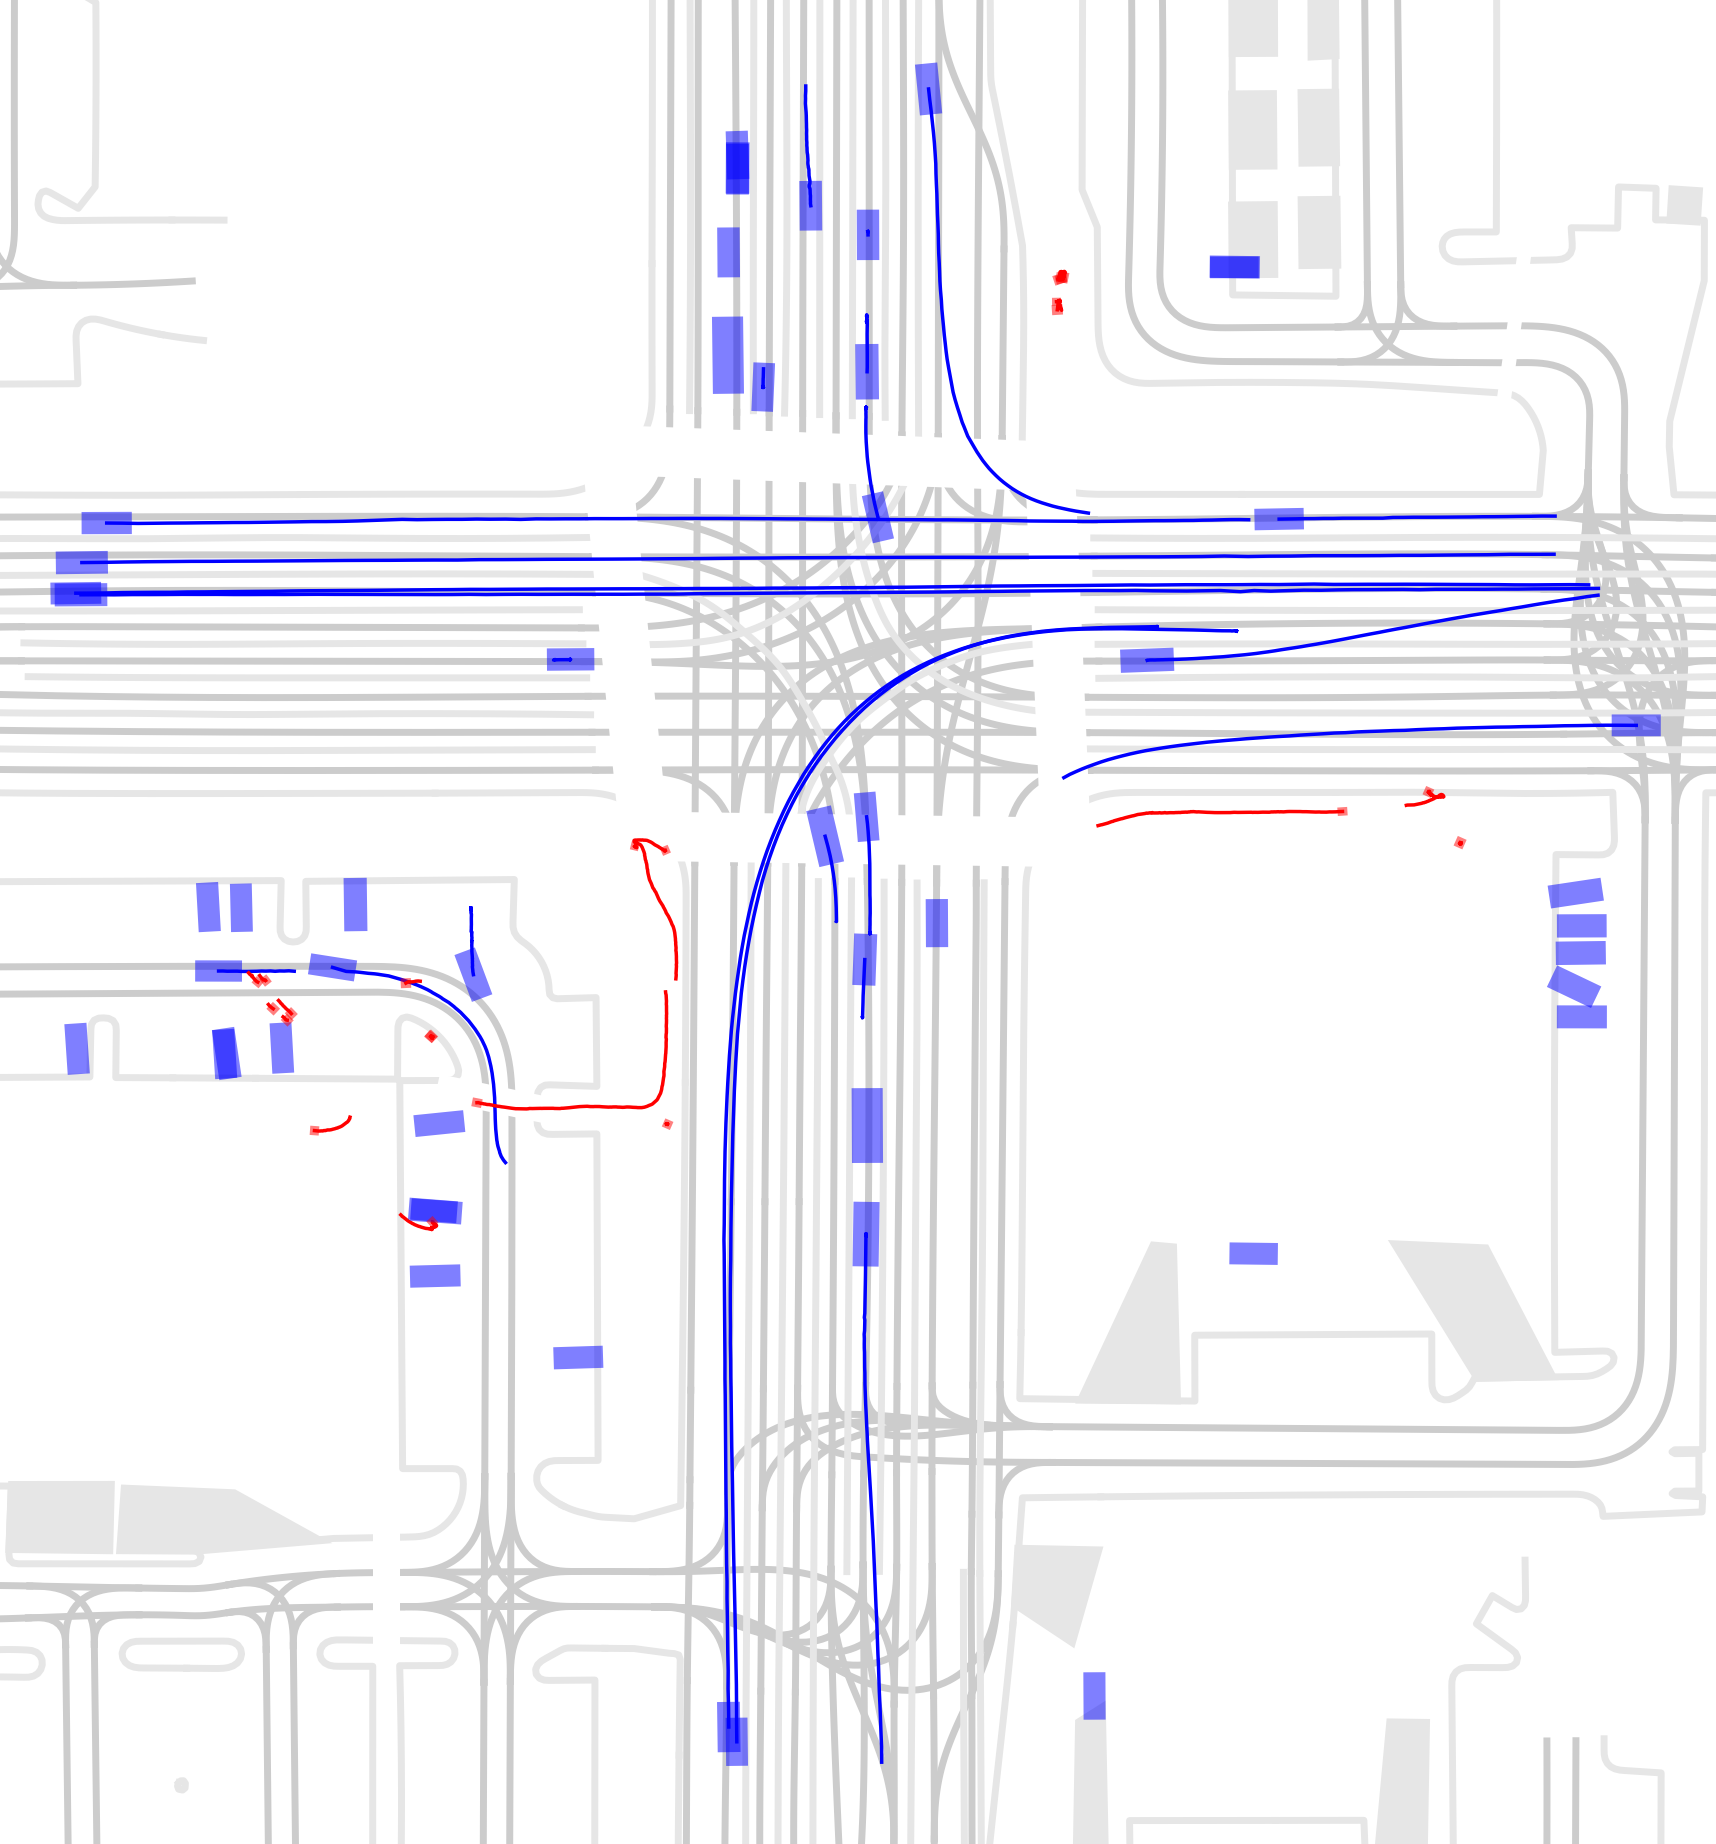

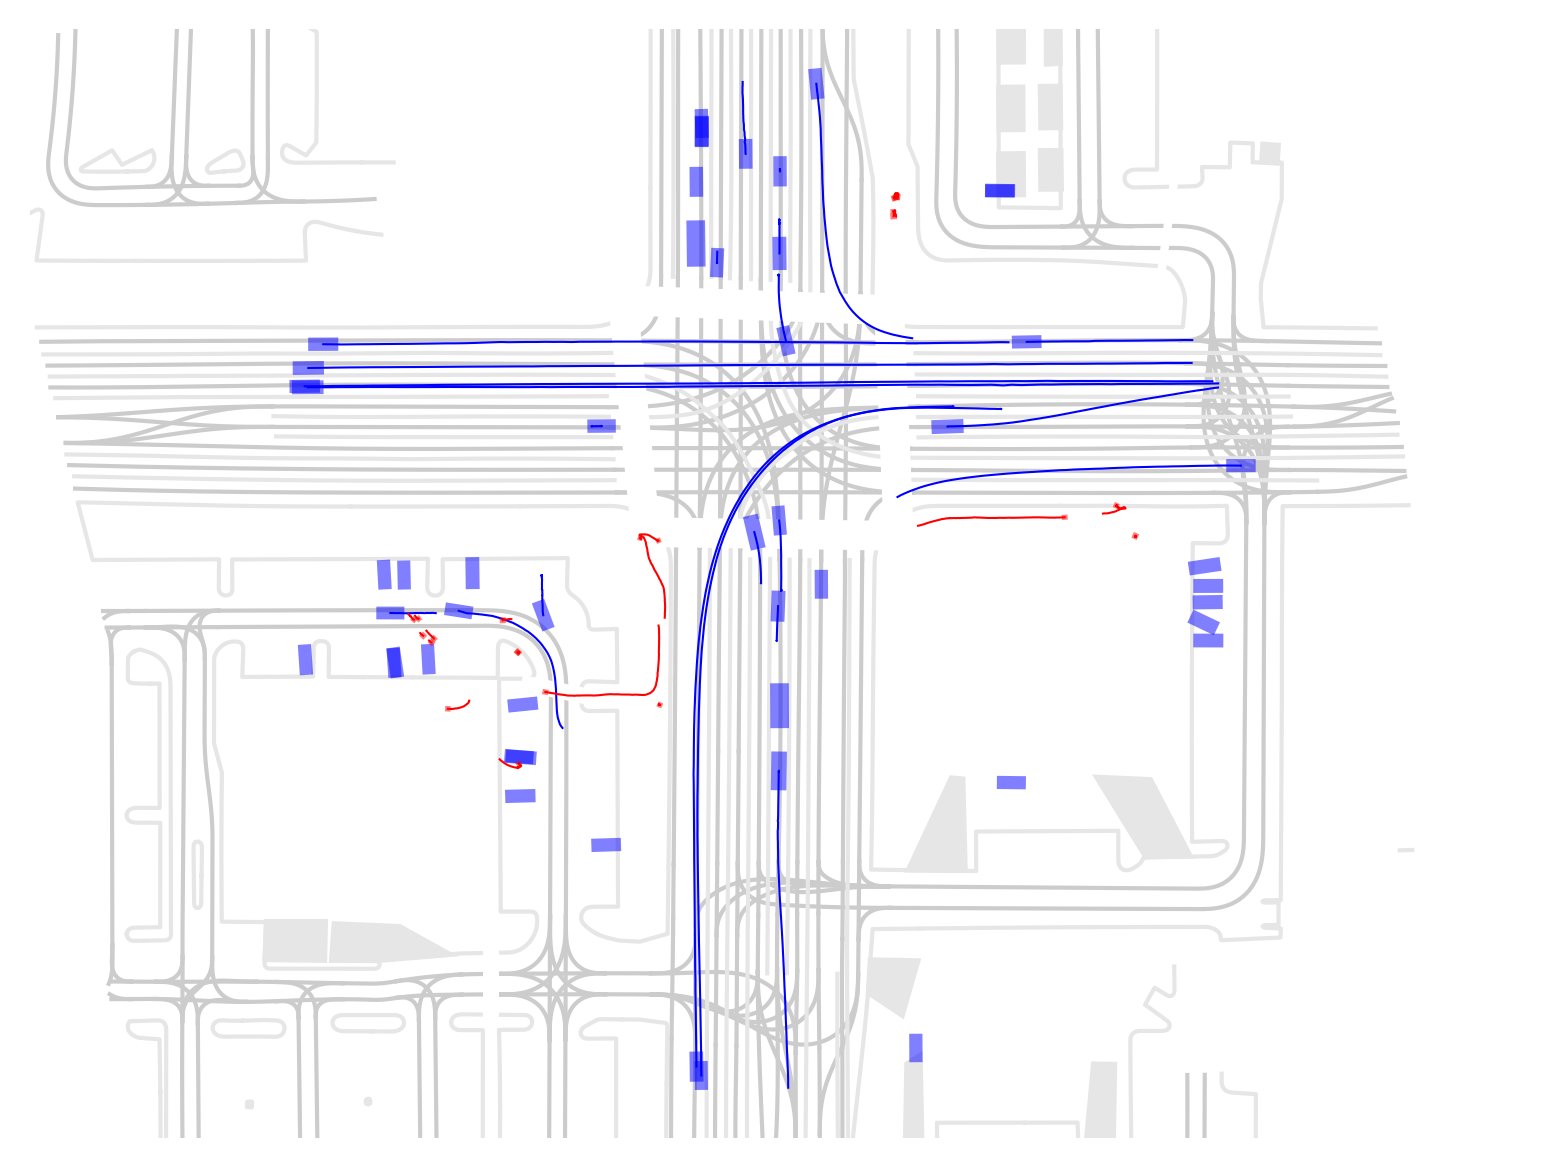

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image

def crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=0, dpi=500):
    """
    从一个 matplotlib Axes 中裁剪指定数据区域，返回 PIL.Image。
    
    参数:
        ax: matplotlib.axes.Axes 对象
        xmin, xmax, ymin, ymax: 数据坐标范围
        pad_pixels: 裁剪时向内缩进像素，避免边线干扰
    
    返回:
        PIL.Image 对象
    """
    fig = ax.figure
    canvas = fig.canvas
    raw_dpi = ax.figure.dpi
    fig.set_dpi(dpi)   # 改变 Figure 的 DPI

    canvas.draw()  # 渲染 Figure
    argb = canvas.tostring_argb()
    w, h = canvas.get_width_height()

    # 坐标 -> 像素转换
    def data_to_pixel(xdata, ydata):
        px, py = ax.transData.transform(np.array([[xdata, ydata]]))[0]
        return int(round(px)), int(round(h - py))  # y 翻转
    
    pxmin, pymin = data_to_pixel(xmin, ymin)
    pxmax, pymax = data_to_pixel(xmax, ymax)

    fig.set_dpi(raw_dpi)  # 恢复原始 DPI

    # Figure 渲染成 RGBA 数组
    buf = np.frombuffer(argb, dtype=np.uint8)
    buf = buf.reshape(h, w, 4)
    buf = buf[:, :, [1, 2, 3, 0]]  # ARGB -> RGBA
    
    # 裁剪区域，加入 pad
    x0, x1 = sorted([pxmin, pxmax])
    y0, y1 = sorted([pymin, pymax])
    
    x0 += pad_pixels
    x1 -= pad_pixels
    y0 += pad_pixels
    y1 -= pad_pixels
    
    cropped = buf[y0:y1, x0:x1]
    return Image.fromarray(cropped)


def get_img(scenario, df, draw_traj=False):
    # LaneCenter lane = 3;
    # RoadLine road_line = 4;
    # RoadEdge road_edge = 5;
    # StopSign stop_sign = 7;
    # Crosswalk crosswalk = 8;
    # SpeedBump speed_bump = 9;
    # Driveway driveway = 10;
    items = {
        'lane': [],
        'road_line': [],
        'road_edge': [],
        'crosswalk': [],
        'driveway': [],
    }
    for item in scenario.map_features:
        if item.HasField('road_edge'):
            road_edge = [(i.x, i.y) for i in item.road_edge.polyline]
            items['road_edge'].append(road_edge)
        elif item.HasField('crosswalk'):
            crosswalk = [(i.x, i.y) for i in item.crosswalk.polygon]
            crosswalk.append(crosswalk[0])  # 闭合
            items['crosswalk'].append(crosswalk)
        elif item.HasField('driveway'):
            driveway = [(i.x, i.y) for i in item.driveway.polygon]
            driveway.append(driveway[0])  # 闭合
            items['driveway'].append(driveway)
        elif item.HasField('lane'):
            lane = [(i.x, i.y) for i in item.lane.polyline]
            items['lane'].append(lane)
        elif item.HasField('road_line'):
            road_line = [(i.x, i.y) for i in item.road_line.polyline]
            items['road_line'].append(road_line)

    xmin, xmax = df['center_x'].min(), df['center_x'].max()
    ymin, ymax = df['center_y'].min(), df['center_y'].max()
    expand_ratio = 0.05
    xmin = xmin - (xmax - xmin) * expand_ratio
    xmax = xmax + (xmax - xmin) * expand_ratio
    ymin = ymin - (ymax - ymin) * expand_ratio
    ymax = ymax + (ymax - ymin) * expand_ratio

    fig, ax = plt.subplots(dpi=300)
    ax.axis('equal')
    ax.axis('off')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.set_facecolor((0.9, 0.9, 0.9))
    # ax.add_patch(
    #     Polygon(np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax], [xmin, ymin]]),
    #     facecolor=(0.95, 0.95, 0.95), edgecolor=None, linewidth=1, zorder=0)
    # )
    for lane in items['lane']:
        ax.plot(*np.array(lane).T, color=(0.8, 0.8, 0.8), linewidth=1, zorder=100)
    for road_line in items['road_line']:
        ax.plot(*np.array(road_line).T, color=(0.9, 0.9, 0.9), linewidth=1, zorder=100)
    for driveway in items['driveway']:
        ax.add_patch(Polygon(np.array(driveway), facecolor=(0.9, 0.9, 0.9), edgecolor=None, zorder=100))
    for road_edge in items['road_edge']:
        ax.plot(*np.array(road_edge).T, color=(0.9, 0.9, 0.9), linewidth=1, zorder=100)
    for crosswalk in items['crosswalk']:
        ax.add_patch(Polygon(np.array(crosswalk), facecolor=(1.0, 1.0, 1.0), edgecolor=None, zorder=100))
    img0 = crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=2, dpi=500)

    if draw_traj:
        for pid, group in df.groupby('id'):
            assert group['type'].nunique() == 1
            if group['type'].iloc[0] == 'VEHICLE':
                color = 'blue'
            elif group['type'].iloc[0] == 'PEDESTRIAN':
                color = 'red'
            else:
                color = 'black'
            plt.plot(group['center_x'], group['center_y'], color=color, lw=0.5, zorder=999)

            data = group.iloc[-1]
            x = data['center_x']
            y = data['center_y']
            width = data['width']
            length = data['length']
            heading = np.degrees(data['heading'])
            polygon = Polygon(np.array([
                [-length/2, -width/2],
                [ length/2, -width/2],
                [ length/2,  width/2],
                [-length/2,  width/2],
                [-length/2, -width/2],
            ]), 
                facecolor=color, edgecolor=None, alpha=0.5,
                transform=plt.matplotlib.transforms.Affine2D().rotate_deg_around(0, 0, heading).translate(x, y) + ax.transData,
                zorder=1000,
            )
            ax.add_patch(polygon)
        img1 = crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=2, dpi=500)
    else:
        img1 = None
    return fig, img0, img1, xmin, xmax, ymin, ymax

fig, img0, img1, xmin, xmax, ymin, ymax = get_img(scenario, df, draw_traj=True)
print(xmin, xmax, ymin, ymax)
display(img0)
display(img1)

In [7]:
fig.savefig('./figures/WayMo_scenario.png', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('./figures/WayMo_scenario.pdf', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('./figures/WayMo_scenario.svg', bbox_inches='tight', dpi=300, transparent=True)